# Mexico Real Estate Price Analysis
## Part 2: Visualizing Housing Data

> **Why can't we just trust the summary statistics from Notebook 1?**
>
> In Notebook 1, `.describe()` put the mean price around $115,000. But that
> number hides everything: the shape of the distribution, where the outliers
> sit, whether price and area are linearly related, and whether location changes
> the story entirely. Numbers summarize; visualizations *reveal*.



## 1. Setup and Data Loading

First, we import the libraries and load the clean dataset created
in Notebook 1: `".../data/mexico-real-estate-combined-clean.csv"`.


In [38]:
import pandas as pd

# Define the path to the clean CSV file saved in Notebook 1
data_path = "../data/mexico-real-estate-combined-clean.csv"

# Load the data
df = pd.read_csv(data_path)

# Verify the load
print(f"Dimensions: {df.shape[0]} rows and {df.shape[1]} columns.")
print(df.info())
df.head()

Dimensions: 1736 rows and 6 columns.
<class 'pandas.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  1736 non-null   str    
 1   state          1736 non-null   str    
 2   lat            1736 non-null   float64
 3   lon            1736 non-null   float64
 4   area_m2        1736 non-null   float64
 5   price_usd      1736 non-null   float64
dtypes: float64(4), str(2)
memory usage: 81.5 KB
None


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


## 2. Univariate Analysis: Understanding One Variable at a Time

Before we look for *relationships* between variables, we must understand each
variable *individually*. 

> For our housing dataset specifically:
>
> | Question | Cannot answer with numbers alone | Visualization that answers it |
> |---|---|---|
> | Is price symmetric or skewed? | `.describe()` hints at skew (mean > median) | Histogram — shows the actual shape |
> | Are there extreme outliers? | `max` gives one number | Histogram + Boxplot — show where outliers cluster |
> | Do prices differ by state? | State means could be computed | Boxplot by state — shows spread, not just center |
> | Is size-price relationship linear? | Correlation gives one number | Scatterplot — shows noise, curves, clusters |
> | Does location change the size-price relationship? | Segmented correlation is possible | Small multiples — three plots side by side |

We will answer these questions in order. We start with histograms to understand
the shape of the price and area distributions.

---


### 2.1 Histogram of `price_usd`

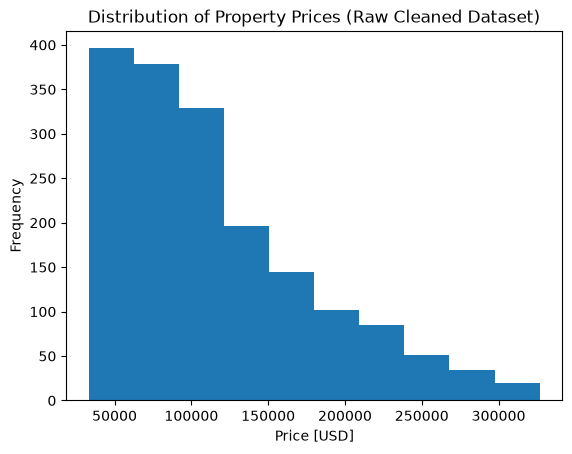

In [39]:
# import matplotlib
import matplotlib.pyplot as plt

# Create a histogram for price
fig, ax = plt.subplots()

# Create a histogram for price_usd
ax.hist(df["price_usd"])

# Add x-axis label, y-axis label & title
ax.set_xlabel("Price [USD]")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Property Prices (Raw Cleaned Dataset)"); # The semi-colon is added to suppress some ugly text and just gives us the graphic.

> **Reading the `price_usd` histogram — right skew in housing data**
>
> **Shape:** The distribution is strongly **right-skewed** (positively skewed). The
> tallest bars are on the left — most properties are priced between 30,000 and
> 130,000. The distribution then tapers off slowly to the right, with a long thin
> tail of expensive properties extending to 300,000+.

### 2.2 Histogram of `area_m2`

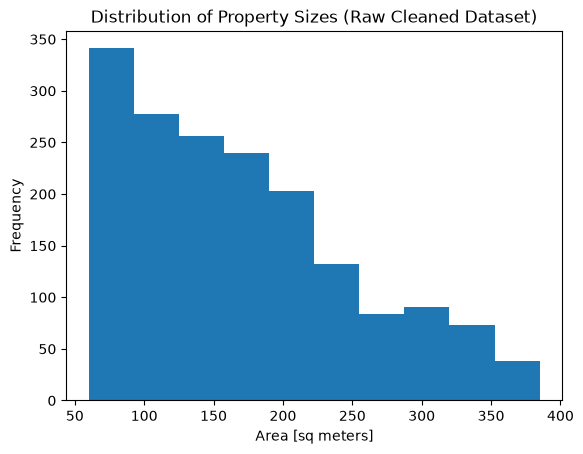

In [41]:
# Create a histogram for area_m2
fig, ax = plt.subplots()

# Use Matplotlib to create histogram of "area_m2"
ax.hist(df["area_m2"])

# Add x-axis label, y-axis label & title
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Property Sizes (Raw Cleaned Dataset)");

> **Reading the `area_m2` histogram — size distribution and what it implies**
>
> **Shape:** Also right-skewed, but for a different reason. Most properties in the
> dataset are apartments or smaller houses (50–150 m²), with a long tail of larger
> properties (mansions or commercial listings that crept into the dataset).
>
> **Comparing the two histograms:**
>
> | Variable | Peak (mode) | Right tail | Implication |
> |---|---|---|---|
> | `price_usd` | ~60,000–80,000 | Long, up to ~327,000 | A few luxury properties inflate the mean |
> | `area_m2` | ~80–120 m² | Long, up to ~1,000 m² | A few large properties inflate the mean |
>
> **Why both are right-skewed:** Both price and area have a physical lower bound
> (a property must have positive size and a positive price) but no mathematical
> upper bound. Any variable with a hard floor but no ceiling tends to be
> right-skewed.

## 3. Bivariate Analysis: Categorical vs. Numerical

Now that we understand each variable individually, we move to **bivariate analysis**
— studying the relationship between two variables simultaneously. We start by
comparing a numerical variable (`price_usd`) against a categorical variable
(`property_type`, `state`). The right tool for this is the boxplot.


### 3.1  Boxplot of `price_usd` by`property_type`

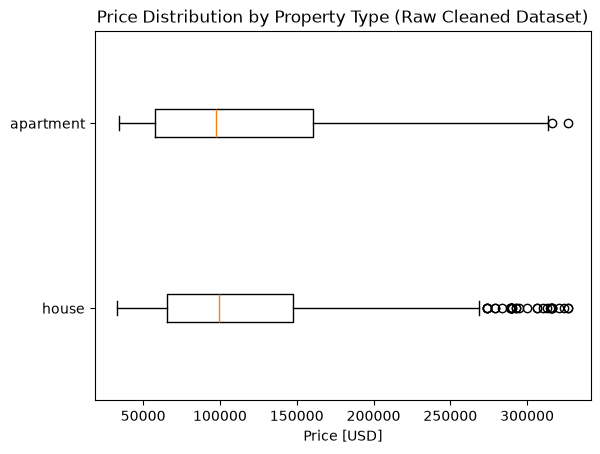

In [42]:
# 1. Get the unique category names on the column "property_type"
prop_types = df["property_type"].unique()

# 2. Prepare the data: Create a list of price arrays, one for each type
data_by_type = [df[df["property_type"] == label]["price_usd"] for label in prop_types]

# 3. Plot
fig, ax = plt.subplots()

# Pass the data list and the labels list
ax.boxplot(data_by_type, tick_labels=prop_types, orientation='horizontal')

ax.set_title("Price Distribution by Property Type (Raw Cleaned Dataset)")
ax.set_xlabel("Price [USD]")

plt.show() # plt.show() acts as the semi-colon, to suppress some ugly text and just give us the graphic.

### 3.2 Comparing States
Create a similar horizontal boxplot of `"price_usd"` by
selected major states. Use the top 3 states by listing count.


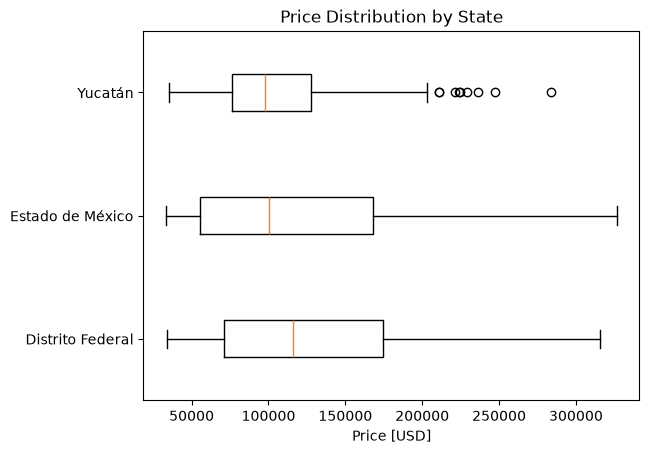

In [43]:
# 1. Define your selected states
selected_states = (
    df["state"]
    .value_counts()
    .head(3)
    .index.tolist()
)
# 2. Prepare the data
data_by_state = [df[df["state"] == state]["price_usd"] for state in selected_states]

# 3. Plot
fig, ax = plt.subplots()

# FIX: Use 'tick_labels' instead of 'labels'
ax.boxplot(data_by_state, tick_labels=selected_states, orientation='horizontal')

ax.set_title("Price Distribution by State")
ax.set_xlabel("Price [USD]")
plt.show()

## 4. Bivariate Analysis: Numerical vs. Numerical

The core of our research question is the relationship between size and price. Does
a bigger property always cost more? Is the relationship consistent, or does it
vary by location?


### 4.1 Scatterplot of area vs price

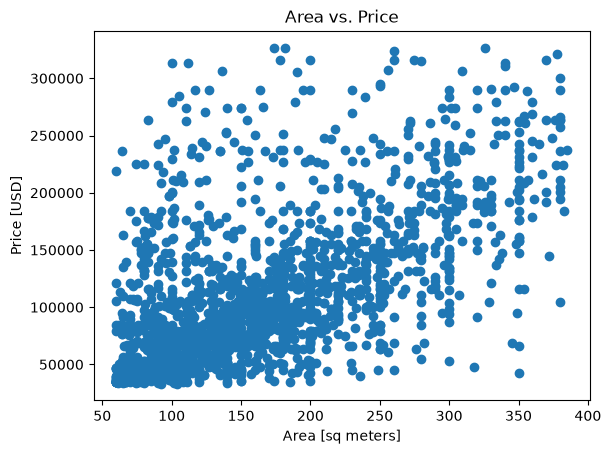

In [44]:
# 1. Create the Figure and Axes objects
fig, ax = plt.subplots()

# 2. Plot on the specific axes object
ax.scatter(x=df["area_m2"], y=df["price_usd"])

# 3. Set labels and title (Note the "set_" prefix)
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price")

plt.show()

> **Reading the raw scatterplot — compression from outliers**
>
> You likely see a dense cluster of points crammed into the lower-left corner, with
> a few isolated points stretching far to the right and upward. This is the classic
> signature of extreme outliers **compressing the visualization**.

### 4.2 Handling Outliers: Quantile-Based Filtering

Original: 1736 rows
Cleaned: 1365 rows
Removed: 371 rows


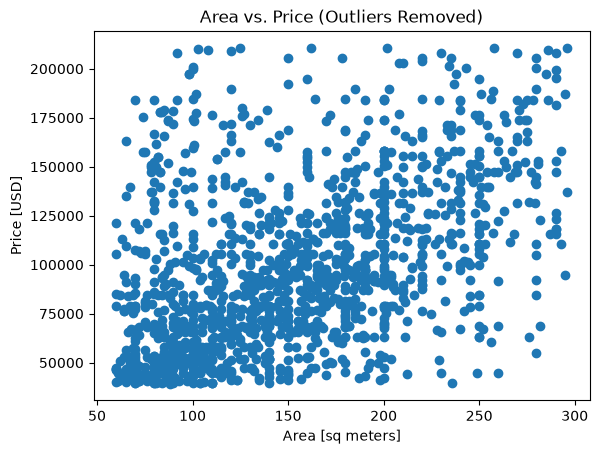

In [45]:
# Define cutoff percentages
lower_cut = 0.05  # Remove bottom 5%
upper_cut = 0.90  # Keep up to 90th percentile

# Filter the data
df_clean = (
    df[
        (df["price_usd"] > df["price_usd"].quantile(lower_cut)) &
        (df["price_usd"] < df["price_usd"].quantile(upper_cut)) &
        (df["area_m2"] < df["area_m2"].quantile(upper_cut)) # <-- Large area outliers also skew the scatter plot
    ]
)

# Show what changed
print(f"Original: {len(df)} rows")
print(f"Cleaned: {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")

# Plot
fig, ax = plt.subplots()
ax.scatter(df_clean["area_m2"], df_clean["price_usd"])
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price (Outliers Removed)")
plt.show()

In [46]:
# Persist the outlier-filtered dataset so Notebook 3 and 4 build on this
df_clean.to_csv("../data/mexico-real-estate-combined-analysis-clean.csv", index=False)

print(
    f"Saved {df_clean.shape[0]} rows (of {df.shape[0]} original) to "
    "'mexico-real-estate-combined-analysis-clean.csv'"
)


Saved 1365 rows (of 1736 original) to 'mexico-real-estate-combined-analysis-clean.csv'


### 4.1 Scatterplot of area vs price (clean)

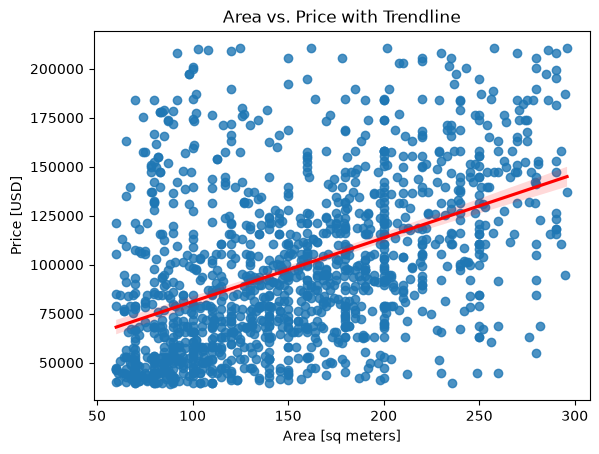

In [47]:
# remember to import your library if you haven't
import seaborn as sns

# Create figure and axis explicitly
fig, ax = plt.subplots()

# Use Seaborn to plot scatter + trendline
sns.regplot(
    data=df_clean, 
    x="area_m2", 
    y="price_usd", 
    line_kws={"color": "red"},  # Make the line distinct
    ax=ax  # Pass the axis to seaborn
)

ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price with Trendline")
plt.show()

## 5. The Influence of Location (Small Multiples)

We have established that **size affects price** — the scatterplot shows a clear
upward slope. But the *strength* of that relationship might vary dramatically by
location. Does a 100 m² house cost the same in Distrito Federal as in Yucatán?
And beyond price, does the relationship between size and price follow the same
pattern in different states?

To answer this, we first need to understand which states have the highest prices —
and then we can compare the size-price relationship across locations.


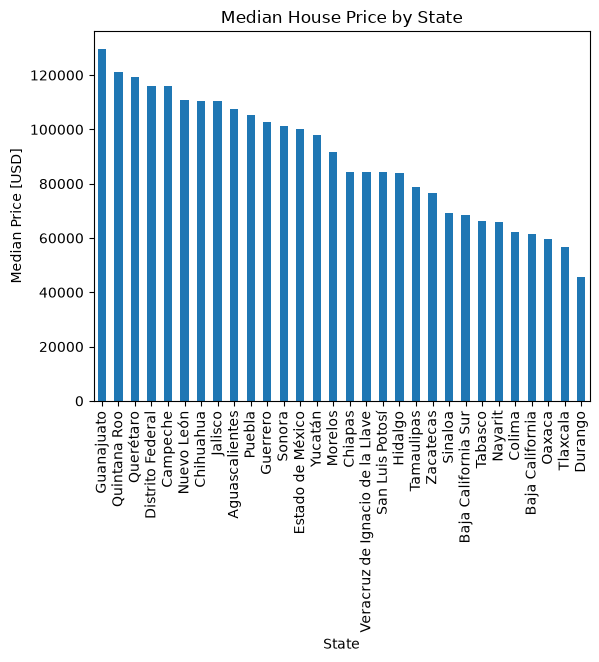

In [48]:
# Aggregate data using groupby
median_price_by_state = (
    df.groupby("state")["price_usd"]  # <-- "state" & "price_usd"
    .median()
    .sort_values(ascending=False) # <-- pass in True or False to sort
)

# Create figure and axes explicitly
fig, ax = plt.subplots()

# Use pandas plot method with explicit axes
median_price_by_state.plot(
    kind="bar",
    ax=ax  # Pass the axes to pandas
)

# Customize using Matplotlib methods
ax.set_xlabel("State")
ax.set_ylabel("Median Price [USD]")
ax.set_title("Median House Price by State")

plt.show()

> **Reading the bar chart — price hierarchy across states**
>
> The bar chart should show Guanajuato with the tallest bar (highest mean
> price), with other states arranged from highest to lowest. This confirms the
> location effect: geography matters.


### 5.2 Small Multiples: Size vs Price by Location

Now that we know which states are most expensive overall, let's examine whether
the *relationship* between size and price is consistent across locations. This is
a fundamentally different question from "which state is expensive?" — it is asking
"does size *explain* price equally well everywhere?"

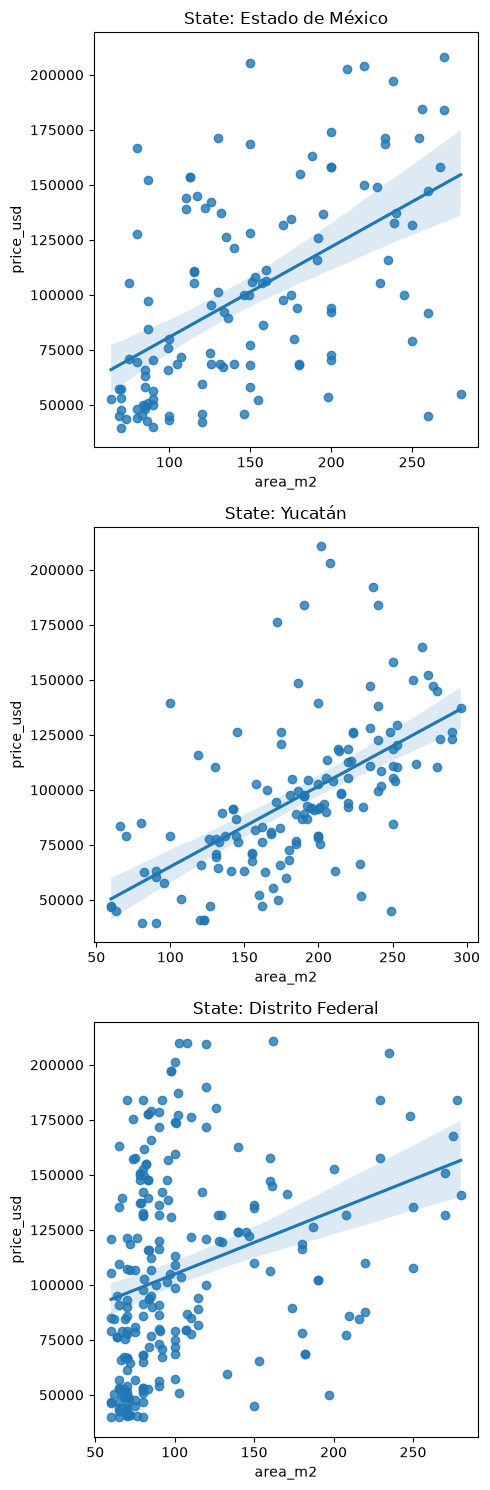

In [49]:
## 1. Create your custom figure and axes
fig, axes = plt.subplots(3, 1, figsize=(5, 15), sharey=True)

# 2. Create a list of the top 3 states
top_states = selected_states  # <--- pass selected_states

# 3. Filter df_clean to include only these states
df_states = df_clean[df_clean["state"].isin(top_states)]

# 4. Loop through the states and plot on each specific axis
states = df_states["state"].unique()

for ax, state in zip(axes, states):
    # Filter data for the current state
    subset = df_states[df_states["state"] == state]
    
    # Use regplot (Axes-level) which ACCEPTS 'ax='
    sns.regplot(
        data=subset,
        x="area_m2",  # <--- "area_m2"
        y="price_usd",  # <--- "price_usd" 
        color='tab:blue', # Optional: keep colors consistent
        ax=ax # <--- This is where you pass the axis explicitly
    )
    
    ax.set_title(f"State: {state}")

plt.tight_layout()
plt.show()